In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import corner

import pickle

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import enterprise.constants as const

from enterprise_extensions import deterministic

from scipy.stats import norm

import libstempo as T2
import libstempo.toasim as LT
import libstempo.plot as LP

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py

In [2]:
target_d_L = 75.4#Mpc

In [3]:
base = "IPTA_MDC2_G2D1_broad_UL_dL_75.4_"
crnr_plt_title1 =base+'corner plot_all_params'
crnr_plt_title2 =base
trace_plot_title = base+'trace_plot'
BF_histogram_title = base+'log10A_histogram'
BFerr_title = base+'log10A_histogram_error'

In [4]:
pwd

'/scratch/na00078/projects/IPTA_MDC2/post_processing'

## Generate Outfile

## Run Outfile

In [5]:
#COMMENT IF OUTFILE GENERATED
#Thinning script for one source
i = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_broad_UL_outfile.h5"
infile = i
first_n_param = 8
# outfile = '/scratch/na00078/QuickCW_targeted_runs/results/3C66B_outfile.h5'

print(infile)
print(first_n_param)

with h5py.File(infile, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:first_n_param]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_broad_UL_outfile.h5
8
(100000000, 8)
(1, 100000000)


## Corner Plots

In [6]:
KPC2S = sc.parsec / sc.c * 1e3
SOLAR2S = sc.G / sc.c ** 3 * 1.98855e30


xxx0 = {"0_cos_gwtheta":np.cos(0.6387905062299246),
       "0_cos_inc":0.8412486994612669,
       "0_gwphi":3.3335788713091694,
       "0_log10_fgw":np.log10(3.7e-09),
       "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651,
        "distance": 75.4,}


xxx = {
       "0_cos_inc":0.8412486994612669,
        "0_log10_fgw":np.log10(3.7e-09),
        "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651}

xxx['gwb_gamma'] = np.nan    
xxx['gwb_log10_A'] = -15.070581074285707
    
#print(xxx)

# In[6]:




hamp [1.8796559e-17 9.3856960e-15 1.0641558e-15 ... 3.8276186e-14 3.9394804e-14
 3.9394804e-14]
freq [1.2984144e-08 1.1251759e-08 7.4217006e-09 ... 9.9419557e-09 9.9419557e-09
 9.9419557e-09]
mc [3.8819533e+10 6.5240605e+10 7.6151854e+09 ... 4.4283519e+10 4.4283519e+10
 4.4283519e+10]
Length of logdL 100000000
required values 8.806164 8.483024e-09 27147040000.0 7.801456e-15
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [7.7729250e+06 3.3613523e+04 6.2627949e+03 ... 3.9788684e+03 3.8658882e+03
 3.8658882e+03]
min 10**log10_d_L 0.001442976
max 10**log10_d_L 639976100.0
d_L_mask [   47197    52679    53372 ... 99929968 99929969 99929970]
notd_L_mask1 [   47447    47448    50038 ... 99930997 99930998 99930999]
notd_L_mask2 [       0        1        2 ... 99999997 99999998 99999999]
merged_non_dL [   47447    47448    50038 ... 99999997 99999998 99999999]
Sample shape (100000000, 9)
dL_mask length 24052
6
Max Mc sampled 9.911766


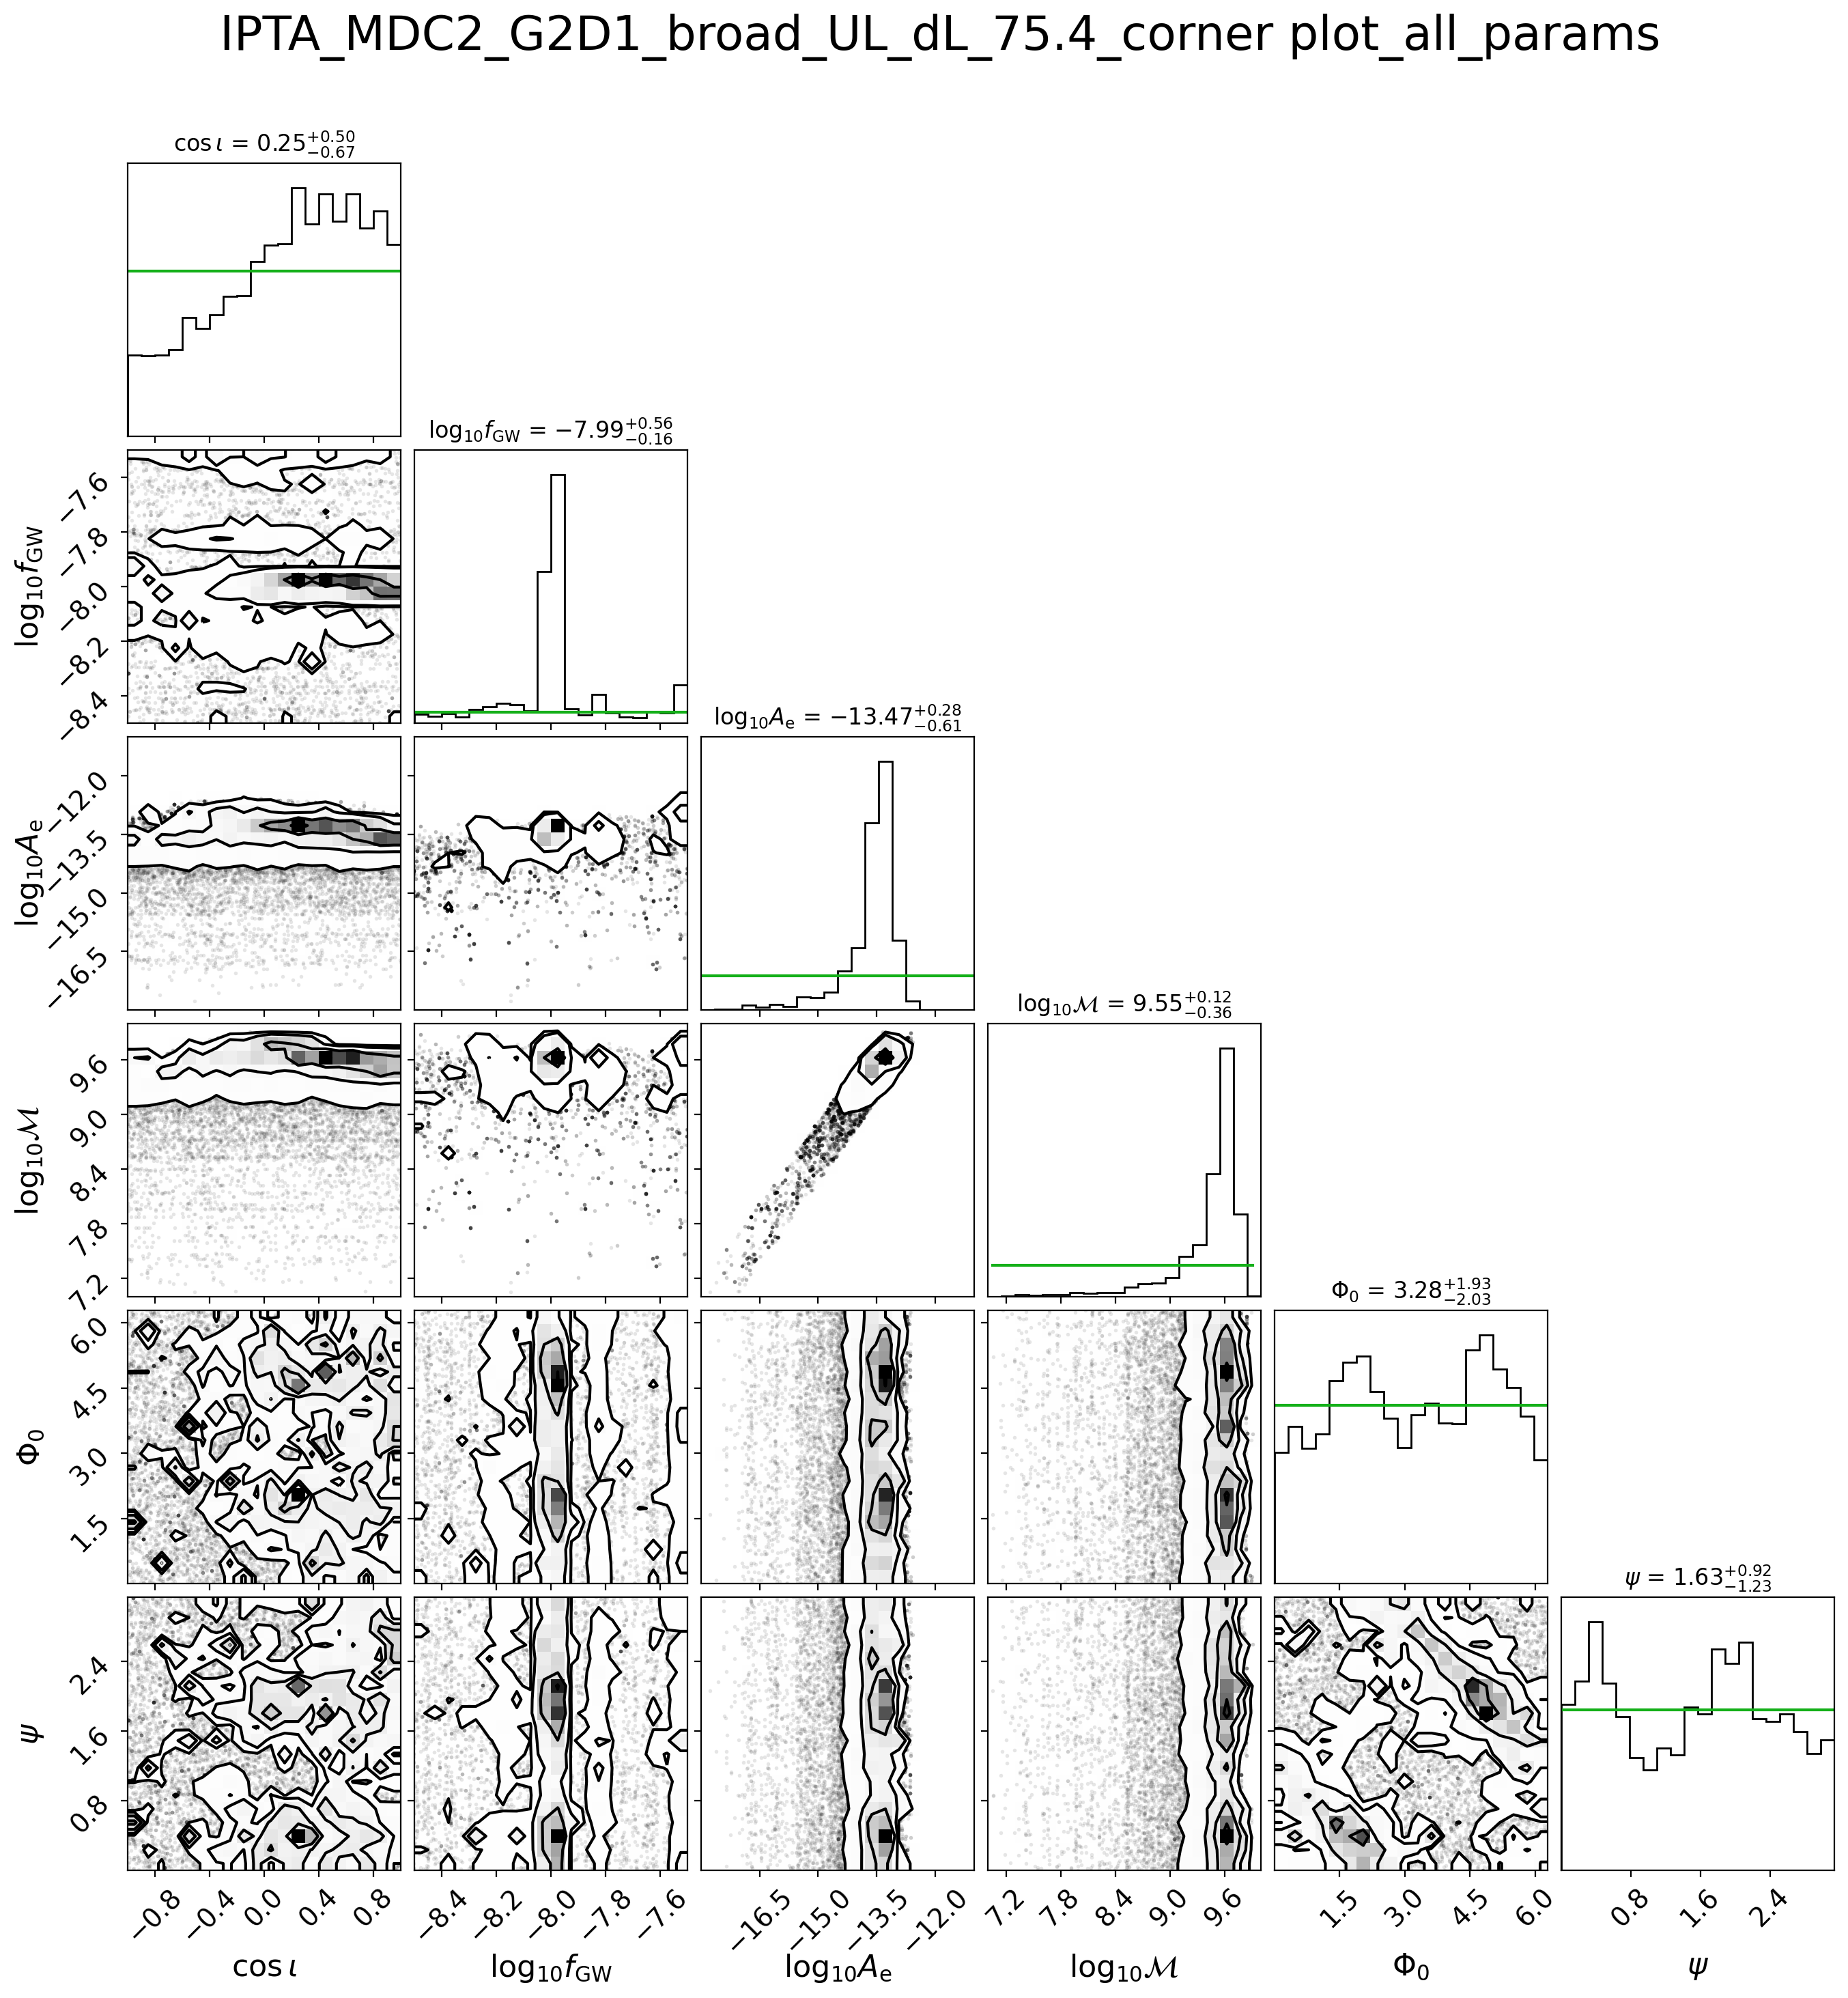

In [7]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
#labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
      #    r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
labels = [r"$\cos \iota$", r"$\log_{10} f_{\rm GW}$", r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$",r"$\psi$"]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
     r"$\log_{10} f_{\rm GW}$":"0_log10_fgw",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi"
}

# Now build the truths array by translating labels
truths = [xxx[label_to_key[l]] for l in labels]


#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-8.5,-7.5), (-18,-11), (7,10), (0,2*np.pi), (0,np.pi)]
#ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.704,np.log10(3e-7)), (-18,-11), (6.6,12), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################

d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

print("Max Mc sampled", np.max(samples2plot[d_L_mask,5]))

samples2plot_detect = np.vstack((
                          samples2plot[d_L_mask,1],
                            samples2plot[d_L_mask,3],
                          samples2plot[d_L_mask,4],
                          samples2plot[d_L_mask,5],
                          samples2plot[d_L_mask,6],
                          samples2plot[d_L_mask,7])).T


#fig = corner.corner(samples2plot_detect,
  #                  labels=labels,
   #                 show_titles=True, quantiles=[0.16, 0.5, 0.84],
    #                range=ranges, hist_kwargs={"density":True})
    
fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True})

for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)   # tick labels
    ax.xaxis.label.set_size(16)                 # x-axis label
    ax.yaxis.label.set_size(16)                 # y-axis label

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==(len(labels)+1): #log10_fgw
         Xs = np.linspace(-9, np.max(samples2plot[d_L_mask,3]))
         ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples2plot[d_L_mask,5]), np.max(samples2plot[d_L_mask,5]))
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==4*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==5*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")

fig.suptitle(crnr_plt_title1, fontsize = 25,y=1.05);

In [ ]:
import numpy as np
import corner

# ---- Labels updated for linear amplitude + chirp mass ----
labels = [r"$\cos \iota$", 
          r"$\log_{10} f_{\rm GW}$", 
          r"$A_{\rm e}$", 
          r"${\cal M}$", 
          r"$\Phi_0$", 
          r"$\psi$"]

burnin = 0
thin = 1

# Convert amplitude and Mc to linear scale
h_amp = 10**samples_cold[0][burnin::thin,4]   # linear amplitude
fff    = 10**samples_cold[0][burnin::thin,3]  # linear frequency
mmm    = 10**samples_cold[0][burnin::thin,5]  # linear chirp mass

# Derived d_L in log10
log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) /
                     h_amp * speed_of_light/megaparsec)

# Rebuild samples array with linear amplitude + chirp mass
samples2plot = np.concatenate(
    (samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L]).T),
    axis=1
)

# Replace log10 amplitude & chirp mass columns
samples2plot[:,4] = h_amp
samples2plot[:,5] = mmm

# Mask on d_L
d_L_mask = np.where((10**log10_d_L >= d_L_min) & (10**log10_d_L <= d_L_max))[0]

# Select subset for plotting
samples2plot_detect = np.vstack((
    samples2plot[d_L_mask,1],  # cos i
    samples2plot[d_L_mask,3],  # log10 fGW
    samples2plot[d_L_mask,4],  # A_e (linear)
    samples2plot[d_L_mask,5],  # Mc (linear)
    samples2plot[d_L_mask,6],  # phase
    samples2plot[d_L_mask,7]   # psi
)).T

# ---- Ranges updated for linear amplitude & chirp mass ----
ranges = [
    (-1, 1),                                      # cos i
    (-9, -7.5),                                   # log10 fGW
    (np.min(h_amp[d_L_mask]), np.max(h_amp[d_L_mask])),  # amplitude (linear)
    (np.min(mmm[d_L_mask]), np.max(mmm[d_L_mask])),      # Mc (linear)
    (0, 2*np.pi),                                 # phase
    (0, np.pi)                                    # psi
]

# Corner plot
fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True}
)

# Formatting
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)

fig.suptitle(crnr_plt_title1, fontsize=25, y=1.05)


hamp [1.8796559e-17 9.3856960e-15 1.0641558e-15 ... 3.8276186e-14 3.9394804e-14
 3.9394804e-14]
freq [1.2984144e-08 1.1251759e-08 7.4217006e-09 ... 9.9419557e-09 9.9419557e-09
 9.9419557e-09]
mc [3.8819533e+10 6.5240605e+10 7.6151854e+09 ... 4.4283519e+10 4.4283519e+10
 4.4283519e+10]
Length of logdL 100000000
required values 8.806164e+00 8.483024e-09 27147040000.0 7.801456e-15
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [7.7729250e+06 3.3613523e+04 6.2627949e+03 ... 3.9788684e+03 3.8658882e+03
 3.8658882e+03]
min 10**log10_d_L 0.001442976
max 10**log10_d_L 639976100.0
d_L_mask [   47197    52679    53372 ... 99929968 99929969 99929970]
notd_L_mask1 [   47447    47448    50038 ... 99930997 99930998 99930999]
notd_L_mask2 [       0        1        2 ... 99999997 99999998 99999999]
merged_non_dL [   47447    47448    50038 ... 99999997 99999998 99999999]
Sample shape (100000000, 9)
dL_mask length 24052
9


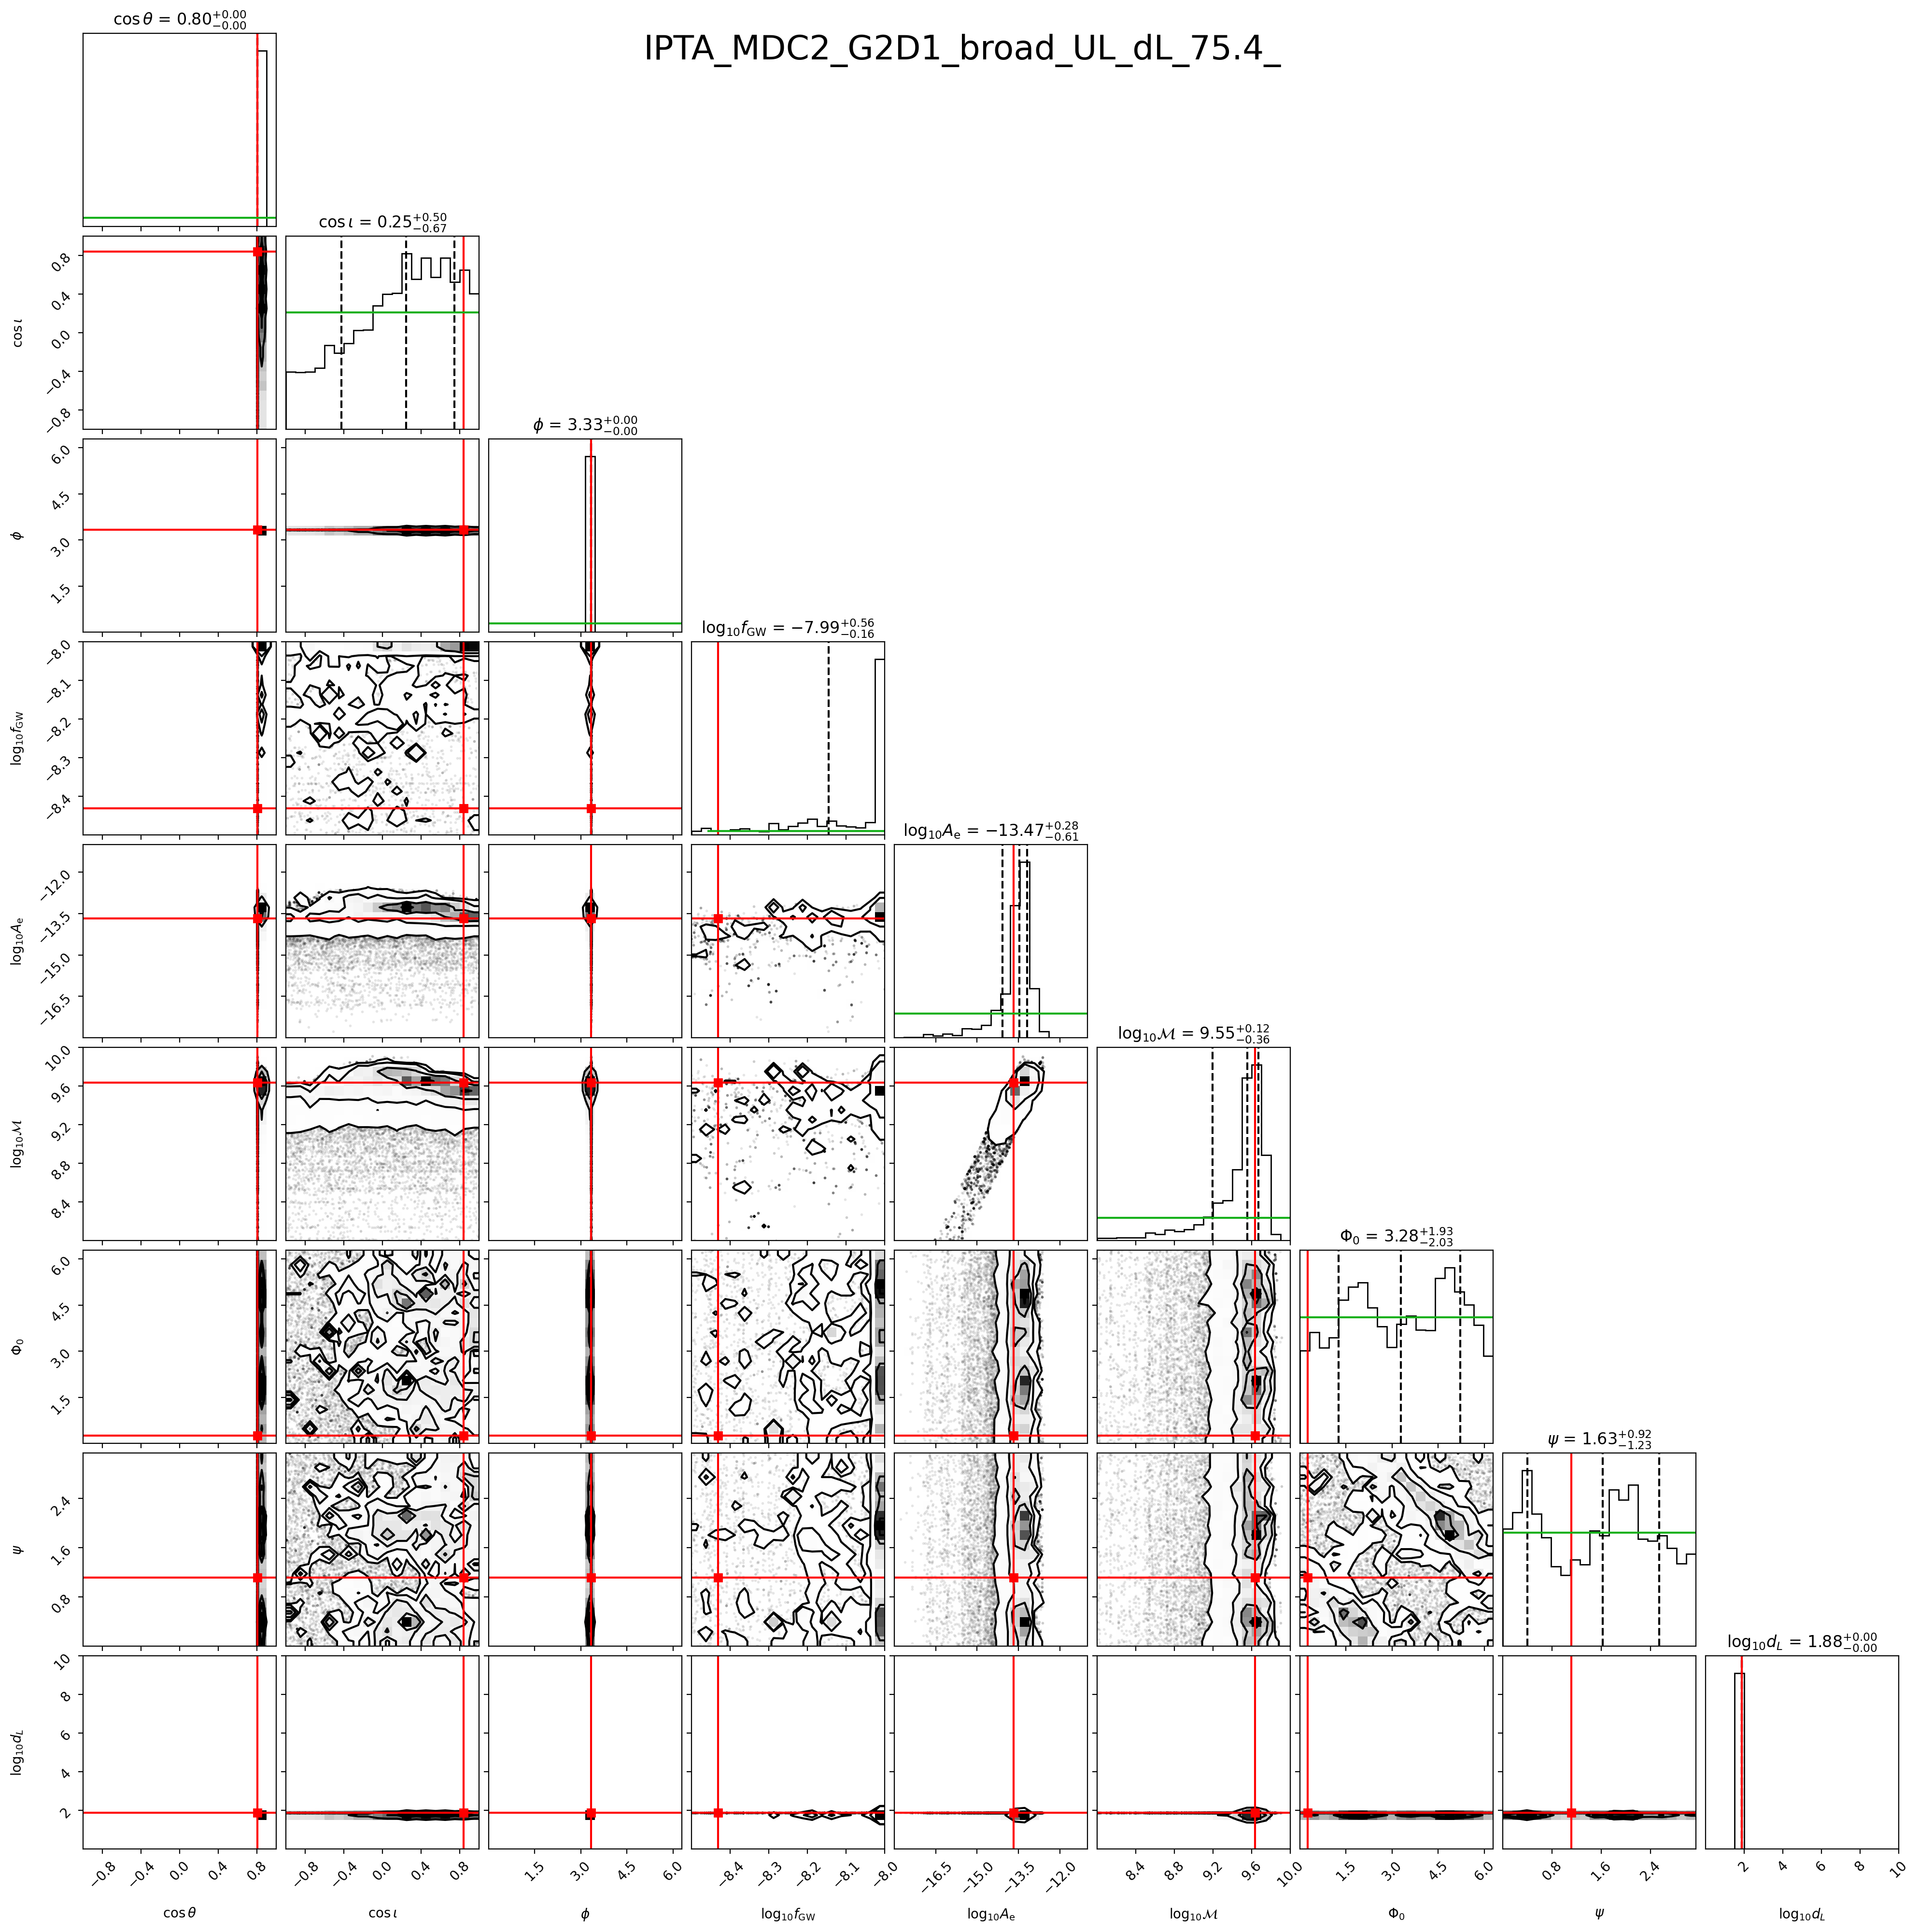

In [8]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
          r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
          
# Mapping from pretty labels → xxx0 keys
label_to_key = {
    r"$\cos \theta$": "0_cos_gwtheta",
    r"$\cos \iota$": "0_cos_inc",
    r"$\phi$": "0_gwphi",
    r"$\log_{10} f_{\rm GW}$": "0_log10_fgw",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi",
    r"$\log_{10} d_L$": "distance"
}

# Build truths list (log-transform distance for d_L)
truths = []
for lab in labels:
    key = label_to_key[lab]
    if lab == r"$\log_{10} d_L$":
        truths.append(np.log10(xxx0[key]))
    else:
        truths.append(xxx0[key])
        
#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.5,-8), (-18,-11), (8,10), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################
target_d_L = 75.4#Mpc
d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

#fig = corner.corner(samples2plot[d_L_mask, :],
 #                   labels=labels,
  #                  show_titles=True, quantiles=[0.16, 0.5, 0.84],
   #                 range=ranges, hist_kwargs={"density":True})

fig = corner.corner(
    samples2plot[d_L_mask, :],   # <-- use samples2plot, not samples2plot_detect
    labels=labels,
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    range=ranges,
    hist_kwargs={"density": True},
    truths=truths,
    truth_color="red"
)

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0 or i==(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==2*(len(labels)+1) or i==6*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_fgw
        Xs = np.linspace(np.log10(3.5e-9), -7.0)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/(np.log10(3e-7)+8.704), color="xkcd:green")
    elif i==4*(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==5*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(7.84, 10.26)
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==7*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")
        
fig.suptitle(crnr_plt_title2, fontsize = 25);

## Trace Plots

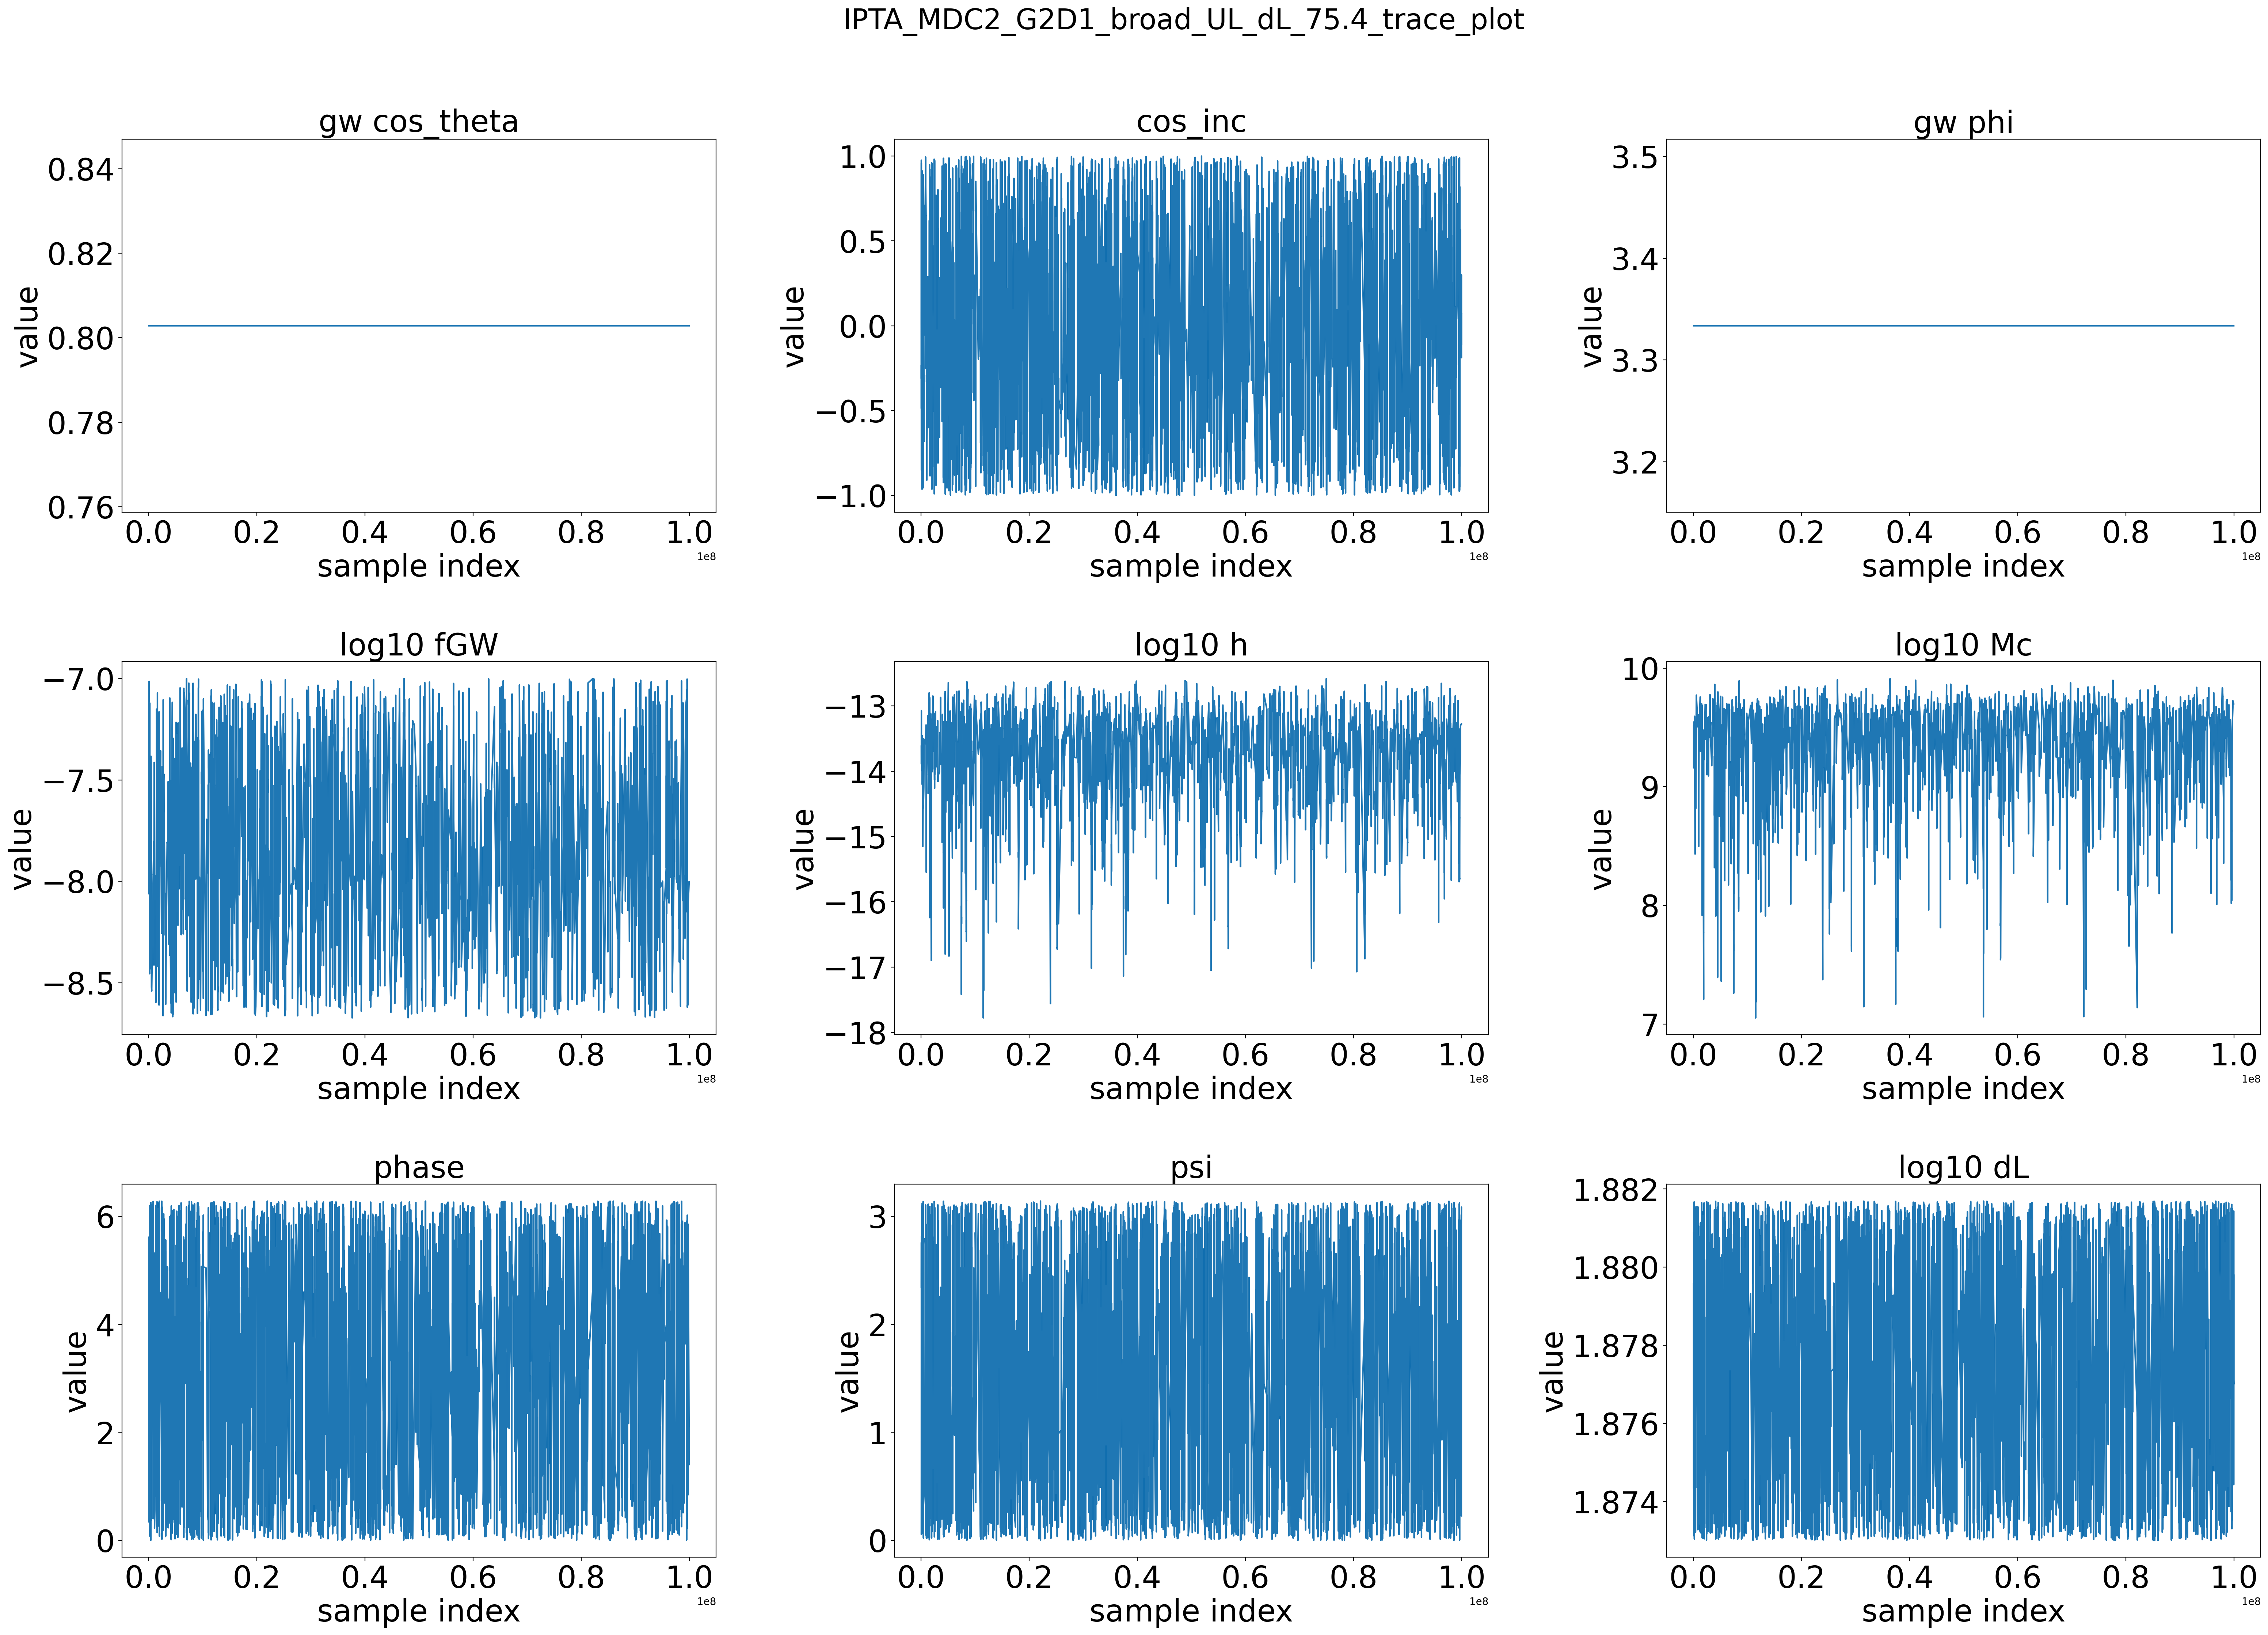

In [9]:
import matplotlib.pyplot as plt

title = ["gw cos_theta", "cos_inc", "gw phi", "log10 fGW", 
         "log10 h", "log10 Mc", "phase", "psi", "log10 dL"]

j = -1
row, column = 3, 3
fig, axs = plt.subplots(row, column, figsize=(30, 20))
fig.tight_layout(h_pad=3, w_pad=2)

# Loop over parameters
for i in range(len(title)): 
    if i % column == 0:
        j += 1
    axs[j, i % column].plot(d_L_mask, samples2plot[d_L_mask, i])
    axs[j, i % column].set_title(title[i], fontsize=30)    # bigger subplot title
    axs[j, i % column].tick_params(axis="both", labelsize=30)  # bigger tick labels
    axs[j, i % column].set_xlabel("sample index", fontsize=30)
    axs[j, i % column].set_ylabel("value", fontsize=30)

# Global title
fig.suptitle(trace_plot_title, fontsize=28, y=1.08)

plt.subplots_adjust(hspace=0.4, wspace=0.3)  # more spacing
#plt.show()
#plt.savefig("trace_plots.png", dpi=200, bbox_inches="tight")


In [10]:
print(np.min(samples2plot[d_L_mask,3]))
print(np.max(np.log10(samples2plot[d_L_mask,5])))

-8.673818e+00
0.99615103


## Upper Limit



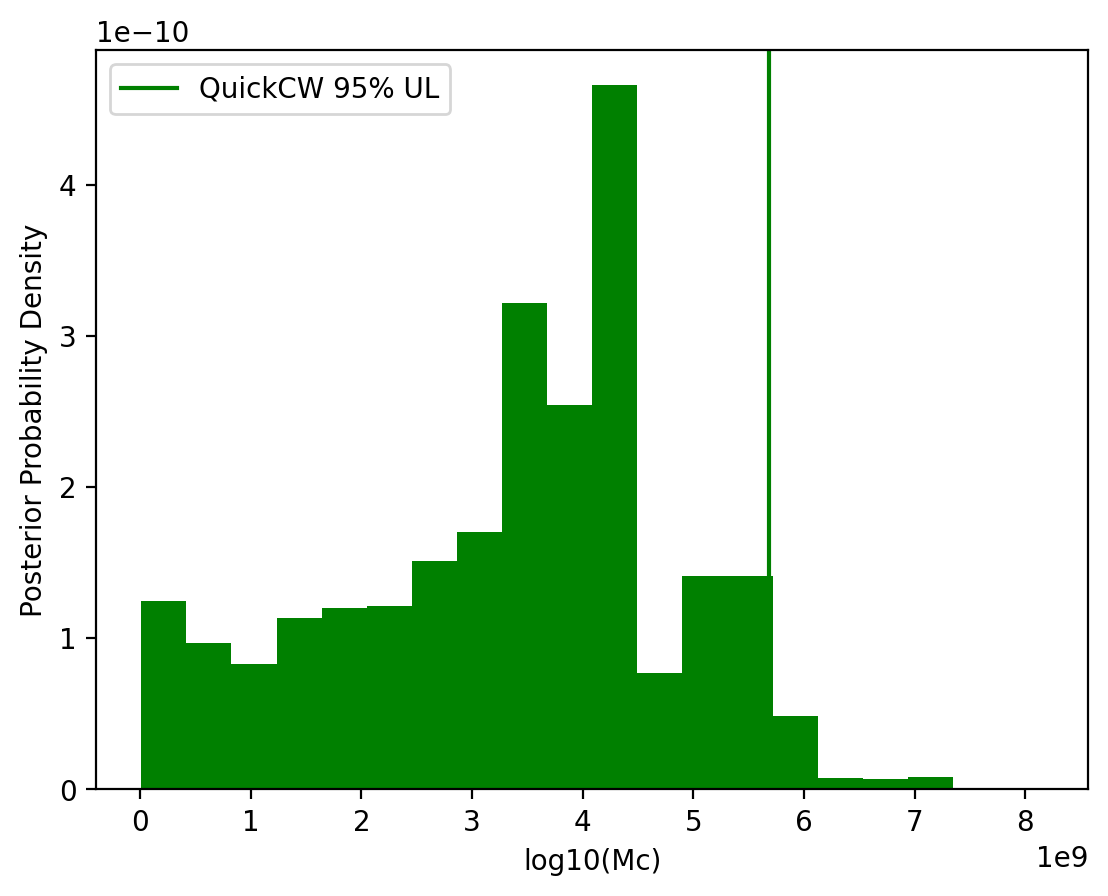

95% Chirp Mass Upper Limit = 5.60068e+09
95% Chirp Mass Upper Limit log10 = 9.74824
95% Chirp Mass Upper Limit Error = 9.94507e+06
95% Chirp Mass Upper Limit Error log10 = 6.99761


In [11]:
#dL Mc Upper limit

logMcmin_dL = np.min(samples2plot[d_L_mask,5])
logMcmax_dL = np.max(samples2plot[d_L_mask,5])

#print(samples2plot[d_L_mask,5])
#print(np.power(10,samples2plot[d_L_mask,5]))

bins=20

counts, bin_edges, _ = plt.hist(np.power(10, samples2plot[d_L_mask,5]), bins=bins, density=True, color='green')

plt.axvline(x = 5.68214e+09,color='green',label= "QuickCW 95% UL")
#plt.axvline(x = 1.34e+09,color='red',label= "12.5yr Upper Limit = 1.34e+09 ")
#plt.title("NGC3115 Upper Limit without J1713 Mc histogram (with dL masking)", y=1.05)
plt.xlabel("log10(Mc)")
plt.ylabel("Posterior Probability Density")
plt.legend()
plt.show()
 
x = np.quantile(np.power(10,samples2plot[d_L_mask,5]), 0.95)

print("95% Chirp Mass Upper Limit = {:0.5e}".format(x))
print("95% Chirp Mass Upper Limit log10 = {:0.5f}".format(np.log10(x)))

#bin_index = np.digitize(np.log10(x), bin_edges) -1
bin_index = np.digitize(x, bin_edges) - 1 

y_value=counts[bin_index]

sigma = np.sqrt((.95*.05)/len(d_L_mask))/y_value
print("95% Chirp Mass Upper Limit Error = {:0.5e}".format(sigma))
print("95% Chirp Mass Upper Limit Error log10 = {:0.5f}".format(np.log10(sigma)))

In [12]:
import numpy as np
from scipy.stats import gaussian_kde

# Number of samples
N = len(d_L_mask)

# Chirp mass in linear scale
mc_samples = np.power(10, samples2plot[d_L_mask,5])

# Confidence level
q = 0.95

# Upper limit = quantile
UL = np.quantile(mc_samples, q)

# Estimate PDF at UL
kde = gaussian_kde(mc_samples)
f_q = kde.evaluate([UL])[0]

# Analytic error estimate
UL_err = np.sqrt(q*(1-q)) / (f_q * np.sqrt(N))

print(f"95% UL (Mc) = {UL:.3e} ± {UL_err:.1e}")


95% UL (Mc) = 5.601e+09 ± 1.1e+07


In [13]:
import numpy as np

def linear_to_log10(UL, UL_err):
    """
    Convert an upper limit and its error from linear scale to log10 scale.

    Parameters
    ----------
    UL : float
        Upper limit in linear scale.
    UL_err : float
        Error on UL in linear scale.

    Returns
    -------
    logUL : float
        log10(UL).
    logUL_err : float
        Error on log10(UL).
    """
    logUL = np.log10(UL)
    logUL_err = UL_err / (UL * np.log(10))
    return logUL, logUL_err



logUL, logUL_err = linear_to_log10(UL, UL_err)
print(f"log10 UL = {logUL:.3f} ± {logUL_err:.4f}")


log10 UL = 9.748 ± 0.0009
